# DNAI

In [1]:
import os
import sys
import pandas as pd
import numpy as np

# Get the project root (parent directory of the notebook folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add it to the Python path
sys.path.append(project_root)

root_dir = os.path.join(project_root, 'data/Dados de Trabalho Anonimizados-20251105T093437Z-1-001/Dados de Trabalho Anonimizados')


* Correr a célula abaixo a primeira vez que executar o notebook para instalar bibliotecas necessárias

In [2]:
#pip install requirements.txt

In [3]:
krippendorff_alpha = {}

In [4]:
df_cats_sup = pd.read_excel(f'{root_dir}/Dados Analistas/Analistas - Empilhada - Tratada V01.xlsx', sheet_name='Sup', usecols="C", skiprows=1, nrows=211)
df_cats_sup.columns = ['categories']
df_cats_sup['categories'] = df_cats_sup['categories'].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

all_cats = set(df_cats_sup['categories'].unique())

## Dados Analistas

In [5]:
df_analysts = pd.read_excel(f'{root_dir}/Dados Analistas/Analistas - Empilhada - Tratada V01.xlsx', sheet_name='Dados Empilhados')

In [6]:
df_analysts_sv = df_analysts[df_analysts['A.01b - Analista'] == 'SV'].copy()
df_analysts_vs = df_analysts[df_analysts['A.01b - Analista'] == 'VS'].copy()

1. Limpeza dos dados

* Nota: Não foram detetados valores em falta ou duplicados no "ID e Nome do Filme" para os dois especialistas

In [7]:
for df in [df_analysts_sv, df_analysts_vs]:
    print(df['ID e Nome do Filme'].duplicated().sum())
    print(df['ID e Nome do Filme'].isna().sum())

0
0
0
0


2. Extração do ID do filme

In [8]:
column = 'ID Filme Novo'

df_analysts_sv['film_id'] = df_analysts_sv[column]
df_analysts_vs['film_id'] = df_analysts_vs[column]

* Nota: O filme "Transcriar" tem dois filmes com o mesmo ID. O mesmo foi observado para os dados de IA

In [9]:
df_analysts_sv[df_analysts_sv['film_id'].duplicated(keep=False)][["ID e Nome do Filme", 'film_id']]

,ID e Nome do Filme,film_id
16,1060106a - Transcriar Audre,1060106
17,1060106b - Transcriar Renata,1060106


3. Extração da primeira categoria

In [10]:
column = 'C.01c - Primeiro Tema'

df_analysts_sv['category'] = df_analysts_sv[column].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
df_analysts_vs['category'] = df_analysts_vs[column].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

### IRR

In [11]:
column_title = 'Nome do Filme'

df_merge_analysts = pd.merge(df_analysts_sv[[column_title, 'film_id', 'category']], df_analysts_vs[['film_id', 'category']], on='film_id', suffixes = ('_SV', '_VS'))
df_merge_analysts.rename(columns={column_title : 'title'}, inplace = True)
df_merge_analysts

,title,film_id,category_SV,category_VS
0,2016 o acesso à USP foi democratizado?,1010101,educação,educação
1,Pixo por institinto,1010102,gênero e sexualidade,cultural
2,O nós de cada um,1020104,gênero e sexualidade,gênero e sexualidade
3,Transpassando,1020107,gênero e sexualidade,gênero e sexualidade
4,A segunda jornada,1030101,família,gênero e sexualidade
...,...,...,...,...
165,Da palha ao bagaço,1110322,cultural,cultural
166,Rimas Cabanas,1110323,cultural,cultural
167,Vazios,1110324,família,"recreação, lazer e entretenimento"
168,O outro lado,1110325,outros,saúde mental


In [12]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(df_merge_analysts["category_SV"], df_merge_analysts["category_VS"])
print("Cohen's kappa:", kappa)

Cohen's kappa: 0.3172187626662737


In [13]:
from statsmodels.stats.inter_rater import fleiss_kappa

categories = sorted(pd.unique(pd.concat([df_merge_analysts["category_SV"], df_merge_analysts["category_VS"]])))

# 2️⃣ Build the rating matrix (rows = items, columns = categories)
M = np.zeros((len(df_merge_analysts), len(categories)), dtype=int)

for i, row in df_merge_analysts.iterrows():
    for r in [row["category_SV"], row["category_VS"]]:
        M[i, categories.index(r)] += 1

# 3️⃣ Compute Fleiss’ Kappa
kappa = fleiss_kappa(M)
print("Fleiss' kappa:", kappa)

Fleiss' kappa: 0.30995959558344344


In [14]:
import krippendorff
import numpy as np

cats = set(df_merge_analysts['category_SV']) | set(df_merge_analysts['category_VS'])
mapper = {c:i for i,c in enumerate(cats)}

r1 = df_merge_analysts["category_SV"].map(mapper)
r2 = df_merge_analysts["category_VS"].map(mapper)

data = np.vstack([r1, r2])  # NaNs stay as np.nan
alpha = krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha)

krippendorff_alpha['analysts'] = alpha

Krippendorff alpha: 0.3119891261846688


* Nota: O alfa de Krippendorff é baixo, há pouca concordância entre os especialistas. Procedeu-se a uma análise mais detalhada para perceber porquê.

### EDA

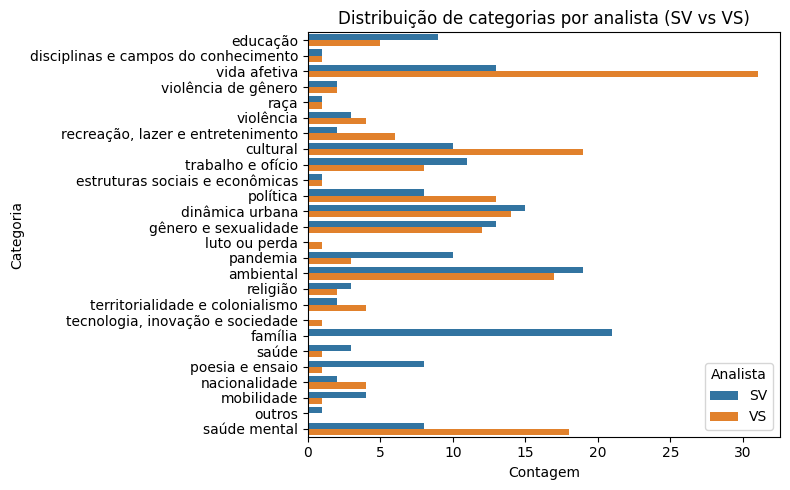

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt dataframe to long format for easier plotting
df_long = pd.melt(
    df_merge_analysts,
    value_vars=['category_SV', 'category_VS'],
    var_name='Rater',
    value_name='Category'
)

# Optional: make the order consistent
rater_labels = {'category_SV': 'SV', 'category_VS': 'VS'}
df_long['Rater'] = df_long['Rater'].map(rater_labels)

# Plot side-by-side counts
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_long,
    y='Category',
    hue='Rater',
    order=cats,      # ensures consistent category order
)

plt.title("Distribuição de categorias por analista (SV vs VS)")
plt.xlabel("Contagem")
plt.ylabel("Categoria")
plt.legend(title='Analista')
plt.tight_layout()
plt.show()


* Nota: Há categorias com elevada disparidade entre analistas, por exemplo cultural, família, saúde mental e vida afetiva

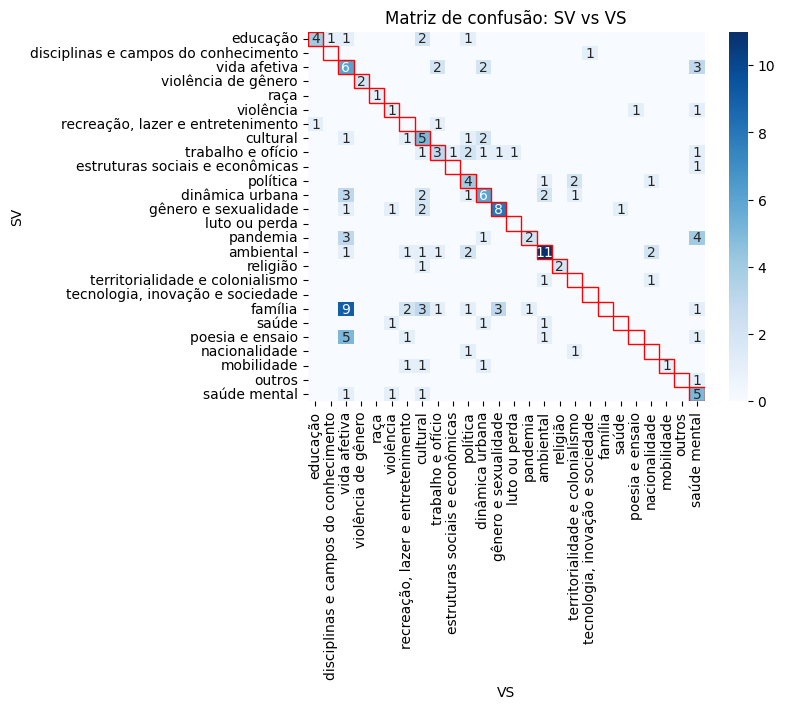

In [16]:
df = df_merge_analysts.copy()

df['category_SV'] = pd.Categorical(df['category_SV'], categories=cats)
df['category_VS'] = pd.Categorical(df['category_VS'], categories=cats)

ct = pd.crosstab(df['category_SV'], df['category_VS'], dropna=False)

# Create a mask of zeros
mask_zeros = ct == 0

# Convert zeros to empty strings for annotation
annot_data = ct.astype(str)
annot_data[mask_zeros] = ""

ax = sns.heatmap(ct, annot=annot_data, cmap="Blues", fmt="")

# --- Draw boxes around diagonal elements ---
for i in range(len(ct)):
    # x, y coordinates are (col, row)
    rect = plt.Rectangle(
        (i, i),              # (x, y)
        1, 1,                # width, height (one cell)
        fill=False,          # no fill
        edgecolor='red',     # box color
        linewidth=1
    )
    ax.add_patch(rect)
ax.set_title("Matriz de confusão: SV vs VS")
ax.set_ylabel('SV')
ax.set_xlabel('VS')
# Force matplotlib to show all tick labels
ax.set_yticks(np.arange(len(ct.index)) + 0.5)   # +0.5 centers labels in cells
ax.set_yticklabels(ct.index, rotation=0)        # or rotation=0 for horizontal

ax.set_xticks(np.arange(len(ct.columns)) + 0.5)
ax.set_xticklabels(ct.columns, )
plt.show()

* Nota: Há maior concordância para as categorias ambiente, cultural, dinâmica urbana, gênero e sexualidade, saúde mental e vida afetiva.
* Nota: Há maior discordância entre: família (SV) e vida afetiva (VS); poesia e ensaio (SV) e vida afetiva (VS)  

In [17]:
df['agree'] = df['category_VS'] == df['category_SV']

print(f"Taxa de concordância: {round(df['agree'].mean()*100,2)} %")

Taxa de concordância: 35.88 %


Text(0.5, 0.98, 'Concordância de analistas por categoria')

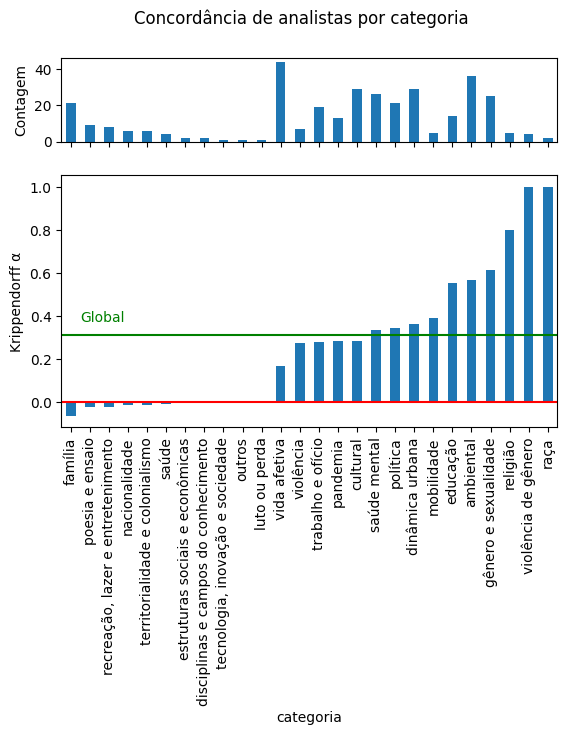

In [18]:
out = []
for cat in cats:
    r1 = (df['category_VS'] == cat).astype(float)
    r2 = (df['category_SV'] == cat).astype(float)

    a = krippendorff.alpha([r1.values, r2.values], level_of_measurement='nominal')
    n1 = int((r1==1).sum())
    n2 = int((r2==1).sum())
    n = n1 + n2
    out.append((n1, n2, n, a))

df_cat_alphas = pd.DataFrame(out, columns=['VS', 'SV', 'N', 'Krippendorff α'], index=list(cats)).sort_values('Krippendorff α')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 3]})

df_cat_alphas['N'].plot(kind='bar', ax=ax1)
ax1.set_ylabel('Contagem')

df_cat_alphas['Krippendorff α'].plot(kind='bar', ax=ax2)
ax2.axhline(0, color='red')
ax2.axhline(krippendorff_alpha['analysts'], color='green')
ax2.text(x=0.5, y=krippendorff_alpha['analysts'] + 0.05, 
        s='Global', 
        color='green', 
        fontsize=10,
        va='bottom',
        ha='left',
        backgroundcolor='white'
        )
ax2.set_ylabel('Krippendorff α')

ax2.set_xlabel('categoria')


fig.suptitle('Concordância de analistas por categoria')


## Dados Autores e Pares

In [19]:
df_authors_peers = pd.read_excel(f'{root_dir}/Dados Autores e Pares/Dados Empilhados Categorizados Limpos Autores e Pares Padronizados V03.xlsx')

In [20]:
df_authors_peers

,Registro,Oficina,IDFIlmes1,IDFilmeOld,Tema 1,Tema 2,Tema 3,Bloco,2009_Como você resumiria este filme? (em poucas palavras),"2010_Quem é/são o(s) personage(m/ns) principa(l/ais) do filme? (podem ser pessoas, lugares, objetos e etc...)",...,2030_B [É um filme que não remetea você a outras obras fílmicas],2031_B [O filme apresenta uma visão imparcial/neutra sobre o tema tratado],2032_B [O filme apresenta uma visão pessoal/íntima sobre o tema],2033_B [O filme apresenta uma visão abstrata/poética sobre o tema],2034_B [O filme apresenta uma visão objetiva/científica sobre o tema],2035_B [O filme demonstra ser fruto de um experimento],2036_B [O filme reflete minha visão de mundo],2037_B [Eu me identifico com o tema abordado pelo filme],IDFIlme,ID_Clear
0,10001,AnF_10a,1100112,1100112,12. Ambiental,18. Cultural,03. Política,B30,É uma ode a Natureza e a necessidade de a ente...,Natureza,...,1,1,3,1,3,1,3,3,1100112.0,1100112.0
1,10002,AnF_10a,1100106,1100106,14. Educação,"23. Tecnologia, Inovação e Sociedade",12. Ambiental,B35,História e importância do papel,O papel,...,1,1,3,2,3,1,3,3,1100106.0,1100106.0
2,10003,AnF_10a,1100111,1100111,25. Luto ou Perda,15. Dinâmica urbana,"19. Recreação, Lazer e Entretenimento",B27,Trata da morte e do que os personagens pensam ...,"Morte , cemitério",...,1,1,3,3,2,1,3,3,1100111.0,1100111.0
3,10004,AnF_10a,1100104,1100104,18. Cultural,36. Alimentação e Tratamentos Tradicionais,14. Educação,B38,Sobre a cultura brasileira e a arte de fazer u...,Pamonha e a chefe que a prepara,...,2,1,3,2,2,1,3,3,1100104.0,1100104.0
4,10005,AnF_10a,1100103,1100103,24. Poesia e Ensaio,17. Vida afetiva,"19. Recreação, Lazer e Entretenimento",B25,Uma exploração poética de imagens desconexas e...,Um personagem indeterminado que participa das ...,...,3,2,3,5,1,5,3,5,1100103.0,1100103.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,12221,AnF_11a,1110138,1110307,24. Poesia e Ensaio,21. Estruturas Sociais e Econômicas,20. Outros,B22,Documental critica,O personagem é a cidade,...,1,3,1,3,5,5,5,5,NaN,NaN
2221,12222,AnF_11a,1110141,1110326,14. Educação,20. Outros,20. Outros,B22,"Filme extremamente informativo, mas com poucas...",A Democracia e as redes sociais,...,5,5,2,2,2,5,5,5,NaN,NaN
2222,12223,AnF_11a,1110160,1110309,31. Linguagem e Representação,"19. Recreação, Lazer e Entretenimento",11. Saúde Mental,B39,Um filme reflexivo e inquietante,Um homem com saúde mental abalada,...,5,1,5,5,2,5,5,5,NaN,NaN
2223,12224,AnF_11a,1110140,1110319,12. Ambiental,"32. Espiritualidade, Religiosidade e Cosmologias",21. Estruturas Sociais e Econômicas,B22,"Um filme simples, mas profundo, que faz reflet...",A natureza (nós),...,2,2,5,5,4,5,5,5,NaN,NaN


1. Extração do ID dos filmes

In [21]:
df_authors_peers['Score Propositivo na Obra'].unique()

array([3, 0, 1, 5])

In [22]:
df_authors_peers[['IDFIlmes1','IDFIlme','ID_Clear']].isna().sum()

IDFIlmes1      0
IDFIlme      396
ID_Clear     396
dtype: int64

In [23]:
df_authors_peers['film_id'] = df_authors_peers['IDFIlmes1']

2. Extração da primeira categoria

In [24]:
df_authors_peers['category'] = df_authors_peers['Tema 1'].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

In [25]:
df_authors_peers[['film_id', 'category']]

,film_id,category
0,1100112,ambiental
1,1100106,educação
2,1100111,luto ou perda
3,1100104,cultural
4,1100103,poesia e ensaio
...,...,...
2220,1110138,poesia e ensaio
2221,1110141,educação
2222,1110160,linguagem e representação
2223,1110140,ambiental


3. Pivot de autores e pares

In [26]:
column_status = '2014b_Status_Participante_Filme'

df_authors = df_authors_peers[df_authors_peers[column_status] == 'Participou'].copy()
df_peers = df_authors_peers[df_authors_peers[column_status] == 'Não Participou'].copy()

df_authors = df_authors[['film_id', 'category']]
df_peers = df_peers[['film_id', 'category']]

df_authors['rater_index'] = df_authors.groupby('film_id').cumcount() + 1
df_peers['rater_index'] = df_peers.groupby('film_id').cumcount() + 1

In [27]:
df_authors_wide = (df_authors.pivot(index='film_id', columns='rater_index', values='category').sort_index(axis=1))
df_authors_wide.columns = [f'category_{idx}' for idx in df_authors_wide.columns]

df_peers_wide = (df_peers.pivot(index='film_id', columns='rater_index', values='category').sort_index(axis=1))
df_peers_wide.columns = [f'category_{idx}' for idx in df_peers_wide.columns]

### IRR

In [28]:
def get_encoding(df):
    cats = pd.Series([x for col in df.columns for x in df[col] if pd.notna(x)]).drop_duplicates()
    cats = sorted(map(str, cats))

    mapping = {c: i for i, c in enumerate(cats)}

    return df.replace(mapping).infer_objects(copy=False)

1. Autores

In [29]:
encoded = get_encoding(df_authors_wide)
data = encoded.to_numpy().T

alpha = krippendorff.alpha(
    reliability_data=data,
    level_of_measurement='nominal'  # or 'ordinal', 'interval', 'ratio'
)

print("Krippendorff’s alpha:", alpha)

krippendorff_alpha['authors'] = alpha

Krippendorff’s alpha: 0.2862814782343225


C:\Users\User01\AppData\Local\Temp\ipykernel_9144\398875418.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.replace(mapping).infer_objects(copy=False)


2. Pares

In [30]:
encoded = get_encoding(df_peers_wide)
data = encoded.to_numpy().T

alpha = krippendorff.alpha(
    reliability_data=data,
    level_of_measurement='nominal'  # or 'ordinal', 'interval', 'ratio'
)

print("Krippendorff’s alpha:", alpha)

krippendorff_alpha['peers'] = alpha

Krippendorff’s alpha: 0.2498025610658079


C:\Users\User01\AppData\Local\Temp\ipykernel_9144\398875418.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.replace(mapping).infer_objects(copy=False)


## Dados IA

### ChatGPT

In [31]:
df_ai_chatgpt = pd.read_excel(f'{root_dir}/Dados IA/AN-IA - SV_ChatGPT_ Formulário de simulação de análise e categorização de filmes por IA (respostas).xlsx')

1. Limpeza dos dados

In [32]:
column = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_ai_chatgpt.drop_duplicates(subset=column, keep='first', inplace=True)
df_ai_chatgpt.dropna(subset=column, inplace=True)

2. Extração de ID do filme

In [33]:
df_ai_chatgpt['film_id'] = df_ai_chatgpt[column].str.extract(r"\)\s*(.*?)\s*-")
df_ai_chatgpt['film_id']

0      1010101
1      1010102
2      1020104
3      1020107
4      1030101
        ...   
164    1110325
165    1110326
166    1080108
167    1090103
168    1110207
Name: film_id, Length: 167, dtype: object

* Nota: Os seguintes filmes têm o mesmo ID

In [34]:
df_ai_chatgpt[df_ai_chatgpt['film_id'].duplicated(keep=False)][[column, 'film_id']]

,D.01 - Qual o filme referente a esta análise simulada de IA?,film_id
16,B01) 1060106 - Transcriar 1 - https://youtu.be...,1060106
17,B01) 1060106 - Transcriar 2 - https://youtu.be...,1060106


3. Extração da primeira categoria

In [35]:
pattern = r'''(?isx)
^
(?:\s*(?:Categoria\s*[A-Z]\s*[-–—]\s*|[A-Z][\.\)]\s*|[A-Z]\s*[–—]\s*))?   # optional prefix
\s*
(.+?)                                                                      # capture main category
(?=                                                                        # stop before optional suffix or end
    \s*
    (?:[-–—]?\s*(?:sub(?:categoria)?\b.*|\(principal\))\s*)?
    $
)
'''

column = 'E.2a) 1 - Categorias/Temas centrais - principal (primeira)'

df_ai_chatgpt['category'] = (df_ai_chatgpt[column].str 
    .extract(pattern, expand=False)
    .str.strip()
    .replace("", pd.NA)
)

df_ai_chatgpt['category']

0            Educação e Desigualdade Social
1        Expressões Marginais e Resistência
2                   Juventudes e Identidade
3                       Identidade e Género
4           Gênero, Maternidade e Sociedade
                       ...                 
164    Ficção & Fantasia Contemporânea (BR)
165          Media Literacy & Desinformação
166     Memória, Resistência e Universidade
167          Processos de Dança & Making-of
168               Eco-ficções & Antropoceno
Name: category, Length: 167, dtype: object

* remover "(principal)" em casos onde persiste

In [36]:
df_ai_chatgpt["category"] = df_ai_chatgpt["category"].str.replace(r"\s*\(principal\)\s*$", "", regex=True).str.strip()



### Gemini

In [37]:
df_ai_gemini = pd.read_excel(f'{root_dir}/Dados IA/AN-IA - VS_Gemini_ Formulário de simulação de análise e categorização de filmes por IA (respostas) (1).xlsx')

1. Limpeza dos dados

In [38]:
column = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_ai_gemini.drop_duplicates(subset=column, keep='first', inplace=True)
df_ai_gemini.dropna(subset=column, inplace=True)

2. Extração do ID do filme

In [39]:
df_ai_gemini['film_id'] = df_ai_gemini['D.01 - Qual o filme referente a esta análise simulada de IA?'].str.extract(r"\)\s*(.*?)\s*-")
df_ai_gemini['film_id']

0      1010101
1      1010102
3      1070103
4      1070105
5      1070106
        ...   
169    1110324
170    1110325
171    1020107
172    1030101
173    1110326
Name: film_id, Length: 167, dtype: object

* Nota: De forma idêntica ao ChatGPT, os seguintes filmes têm o mesmo ID

In [40]:
df_ai_gemini[df_ai_gemini['film_id'].duplicated(keep=False)][[column, 'film_id']]

,D.01 - Qual o filme referente a esta análise simulada de IA?,film_id
160,B01) 1060106 - Transcriar 1 - https://youtu.be...,1060106
161,B01) 1060106 - Transcriar 2 - https://youtu.be...,1060106


3. Extração da primeira categoria

In [41]:
prefix_re = r'^(?:.*?(Tema\s+Principal:?|1\.|Principal(?:\s*\(Strong\s*Match\))?|\*\*|\|\s*\*\*|Recomendação)\s*|\|\s*)'
suffix_re = r'(?:\t|:|\*\*\s*\|?|\*\*\s*\|\s*|\(Prioritário).*'

column = 'E.2a) 1 - Categorias/Temas centrais - principal (primeira)'

df_ai_gemini['category'] = (df_ai_gemini[column].str 
    .replace(prefix_re, "", regex=True)
    .str.replace(suffix_re, "", regex=True)
    .str.strip()
    .replace("", pd.NA)
)

df_ai_gemini['category']

0                                           NaN
1                                           NaN
3                         Arte e Poesia Visual.
4                             Emoções e Memória
5                             Gênero e Pandemia
                         ...                   
169                         Notícias e Política
170                           Filmes e Animação
171    Identidade de Gênero e Experiência Trans
172                  Feminismo e Crítica Social
173                         Notícias e Política
Name: category, Length: 167, dtype: object

In [42]:
# Substituir células vazias (nan) por células sem texto
df_ai_gemini['category'] = df_ai_gemini['category'].astype(str).replace("nan", "")

* Nota: Alguns tópicos contêm descriçoes longas, possivelmente múltiplas atribuições de categorias ou atribuição de sub categorias. Não é possível extrair simplesmente pela separação por vírgulas, porque em alguns casos de categorias, estas contêm também vírgulas.

In [43]:
df_ai_gemini[df_ai_gemini['category'].str.contains(',')][[column, 'category']]

,E.2a) 1 - Categorias/Temas centrais - principal (primeira),category
8,"Trabalho, Imigração e Cultura Urbana.","Trabalho, Imigração e Cultura Urbana."
12,"Abandono, Solidão e Existencialismo.","Abandono, Solidão e Existencialismo."
14,"Dança Urbana, Isolamento e Paisagem Urbana.","Dança Urbana, Isolamento e Paisagem Urbana."
15,"Arte, Natureza e Etnografia","Arte, Natureza e Etnografia"
17,"Verdade, Mentira e Percepção da Realidade.","Verdade, Mentira e Percepção da Realidade."
20,"Urbanismo, Segregação e Desigualdade Social.","Urbanismo, Segregação e Desigualdade Social."
21,"Candomblé, Espiritualidade e Resistência Negra.","Candomblé, Espiritualidade e Resistência Negra."
24,"Memória, História de Vida e Resistência Política.","Memória, História de Vida e Resistência Política."
25,"Arte, Vulnerabilidade e Confinamento.","Arte, Vulnerabilidade e Confinamento."
26,"Solidão, Isolamento Social e Consequências da ...","Solidão, Isolamento Social e Consequências da ..."


### IRR

In [44]:
column_title = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_merge_ai = pd.merge(df_ai_chatgpt[[column_title, 'film_id', 'category']], df_ai_gemini[['film_id', 'category']], on='film_id', suffixes = ('_ChatGPT', '_Gemini'))
df_merge_ai.rename(columns={column_title : 'title'}, inplace=True)
df_merge_ai

,title,film_id,category_ChatGPT,category_Gemini
0,B01) 1010101 - 2016 o acesso à USP foi democra...,1010101,Educação e Desigualdade Social,
1,B01) 1010102 - Pixo por institinto - https://y...,1010102,Expressões Marginais e Resistência,
2,B01) 1020104 - O nós de cada um - https://yout...,1020104,Juventudes e Identidade,LGBTQIA+ & Gênero
3,B01) 1020107 - Transpassando - https://youtu.b...,1020107,Identidade e Género,Identidade de Gênero e Experiência Trans
4,B01) 1030101 - A segunda jornada - https://you...,1030101,"Gênero, Maternidade e Sociedade",Feminismo e Crítica Social
...,...,...,...,...
163,B09) 1110325 - O outro lado - https://youtu.be...,1110325,Ficção & Fantasia Contemporânea (BR),Filmes e Animação
164,B09) 1110326 - Narrativas Fotográficas e Cenár...,1110326,Media Literacy & Desinformação,Notícias e Política
165,B02) 1080108 - O Contínuo Vida - https://www.y...,1080108,"Memória, Resistência e Universidade","Memória, História de Vida e Resistência Política."
166,B05) 1090103 - O que te faz pulsar? - https://...,1090103,Processos de Dança & Making-of,"Artes Performáticas e Dança Flamenco, Sapatead..."


In [45]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(df_merge_ai["category_ChatGPT"], df_merge_ai["category_Gemini"])
print("Cohen's kappa:", kappa)

Cohen's kappa: 0.0


c:\Users\User01\Documents\DNAI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\User01\Documents\DNAI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\User01\Documents\DNAI\.venv\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\Users\User01\Documents\DNAI\.venv\Lib\site-packages\sklearn\utils\multiclass.p

In [46]:
from statsmodels.stats.inter_rater import fleiss_kappa
import numpy as np

categories = sorted(pd.unique(pd.concat([df_merge_ai["category_ChatGPT"], df_merge_ai["category_Gemini"]])))

# 2️⃣ Build the rating matrix (rows = items, columns = categories)
M = np.zeros((len(df_merge_ai), len(categories)), dtype=int)

for i, row in df_merge_ai.iterrows():
    for r in [row["category_ChatGPT"], row["category_Gemini"]]:
        M[i, categories.index(r)] += 1

# 3️⃣ Compute Fleiss’ Kappa
kappa = fleiss_kappa(M)
print("Fleiss' kappa:", kappa)

Fleiss' kappa: -0.007136739937196687


In [47]:
import krippendorff

cats = sorted(pd.unique(pd.concat([df_merge_ai["category_ChatGPT"], df_merge_ai["category_Gemini"]]).dropna()))
mapper = {c:i for i,c in enumerate(cats)}

r1 = df_merge_ai["category_ChatGPT"].map(mapper)
r2 = df_merge_ai["category_Gemini"].map(mapper)

data = np.vstack([r1, r2]).astype(float)  # NaNs stay as np.nan
alpha = krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha)

krippendorff_alpha['IA'] = alpha

Krippendorff alpha: -0.00413930916357419


### Mapeamento AI

In [48]:
cats_ai = set(df_merge_ai['category_ChatGPT']) | set(df_merge_ai['category_Gemini'])

cats_ai.intersection(all_cats)

set()

In [49]:
from sentence_transformers import SentenceTransformer, util

cats_list = list(all_cats)
other_list = list(cats_ai)

# give labels some context to help the embedding model
def add_context(label: str) -> str:
    return f"Tópico de filme: {label}"

cats_with_ctx = [add_context(x) for x in cats_list]
other_with_ctx = [add_context(x) for x in other_list]

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

# Encode labels (normalized for cosine via dot product)
emb_cats = model.encode(cats_with_ctx, normalize_embeddings=True)
emb_other = model.encode(other_with_ctx, normalize_embeddings=True)

# Cosine similarity matrix: shape (len(other) x len(all))
sim_matrix = emb_other @ emb_cats.T   # because embeddings are normalized

# For each "other" label, find best match
best_cat_idx = sim_matrix.argmax(axis=1)
best_sim = sim_matrix.max(axis=1)

# Build mapping dict (optionally apply a similarity threshold)
threshold = 0.50  # tune this
mapping = {}
for i, other_label in enumerate(other_list):
    sim = best_sim[i]
    gold_label = cats_list[best_cat_idx[i]]
    if sim >= threshold:
        mapping[other_label] = (gold_label, float(sim))
    else:
        mapping[other_label] = (None, float(sim))  # no good match

df_map = pd.DataFrame(
    {
        "ai": other_list,
        "all_cats": [mapping[o][0] for o in other_list],
        "similarity": [mapping[o][1] for o in other_list],
    }
).sort_values("similarity", ascending=False)

final_mapping = {k: v for k, (v, s) in mapping.items() if v is not None}



c:\Users\User01\Documents\DNAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
df_map

,ai,all_cats,similarity
78,Educação,educação,0.994254
239,Ciências Humanas e Sociais,ciências sociais e humanas,0.993000
110,Poético/ensaístico,poesia e ensaio,0.973258
48,Poética do Cotidiano,poesia e ensaio,0.959673
251,Natureza Poética & Aves,poesia e ensaio,0.957392
...,...,...,...
172,Agroecologia & Soberania Alimentar,ambiental,0.573642
227,"Artes Performáticas e Dança Flamenco, Sapatead...",cultural,0.573301
282,"Memória Familiar e Afetiva, Luto e Legado, Ens...",cultural,0.572509
279,Resposta a Desastres & Ajuda Humanitária (Brasil),direitos humanos,0.540259


<Axes: >

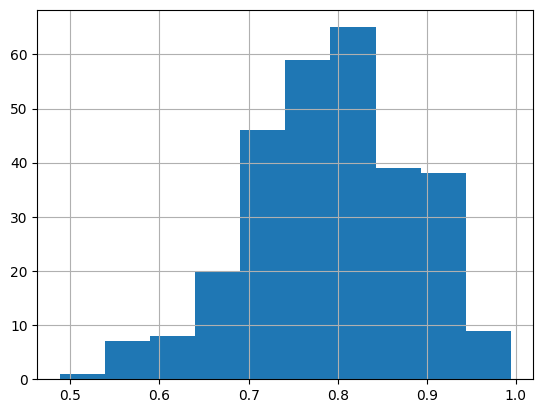

In [51]:
df_map['similarity'].hist()

TODO: relatorio com categorias com maior e menor divergencia

In [52]:
df_category_maps =  df_map.groupby('all_cats')['ai'].agg(list).to_frame()
df_category_maps


,ai
all_cats,
ambiental,"[Sustentabilidade e Meio Ambiente, Meio Ambien..."
ciências sociais e humanas,[Ciências Humanas e Sociais]
cultural,"[Cultura e Tradição, Arte e Cultura, Cultura e..."
dinâmica urbana,"[Retratos & Personagens Urbanos, Questões Soci..."
direitos humanos,"[Direitos Humanos e Ativismo, Ativismo e Direi..."
disciplinas e campos do conhecimento,"[Cinema de Arte e Teoria do Cinema, Filosofia ..."
economia e sociedade,"[Trabalho e Economia, Gig Economy & Imigração]"
educação,"[Educação, Educação e Acesso, Educação e Carre..."
estruturas sociais e econômicas,"[Crítica ao Capitalismo, Desigualdade Social, ..."


In [53]:
df_merge_ai['category_ChatGPT_mapped'] = df_merge_ai['category_ChatGPT'].map(final_mapping)
df_merge_ai['category_Gemini_mapped'] = df_merge_ai['category_Gemini'].map(final_mapping)

In [54]:
cats = set(df_merge_ai["category_ChatGPT_mapped"]) | set(df_merge_ai["category_Gemini_mapped"])
mapper = {c:i for i,c in enumerate(cats)}

r1 = df_merge_ai["category_ChatGPT_mapped"].map(mapper)
r2 = df_merge_ai["category_Gemini_mapped"].map(mapper)

data = np.vstack([r1, r2]).astype(float)  # NaNs stay as np.nan
alpha = krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha)

krippendorff_alpha['IA_mapped'] = alpha

Krippendorff alpha: 0.21519629853776634


## Intra RR para diferentes eixos

Text(0.5, 1.0, 'Inter Rater Reliability')

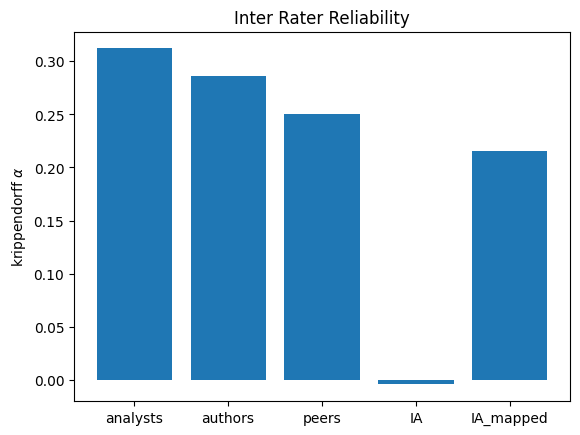

In [55]:
import matplotlib.pyplot as plt

plt.bar(krippendorff_alpha.keys(), krippendorff_alpha.values())
plt.ylabel(r'krippendorff $\alpha$')
plt.title('Inter Rater Reliability')

TODO: medir variabilidade/riqueza de texto dos transcripts

## IRR

In [56]:
def extract_category_values(dfs_by_name, pattern="category", normalize=True):
    """
    dfs_by_name: dict like {"authors": df_authors, "peers": df_peers, ...}
    Returns:
      - cat_by_df: dict[name] -> sorted list of unique categories in that DF
      - cat_all:   sorted list of unique categories across all DFs
      - counts:    Series with global value counts across all matching columns
    """
    cat_by_df = {}
    global_series = []

    for name, df in dfs_by_name.items():
        # columns containing the pattern (case-insensitive)
        cat_cols = [c for c in df.columns if pattern.lower() in c.lower()]
        if not cat_cols:
            continue

        # stack all category columns in this DF
        s = pd.concat([df[c] for c in cat_cols], ignore_index=True)

        # drop NaN and (optionally) normalize
        s = s.dropna()
        if normalize:
            s = s.astype(str).str.strip().str.lower()
        else:
            s = s.astype(str).str.strip()

        # save per-DF uniques
        cat_by_df[name] = sorted(pd.unique(s))

        # keep for global stats
        global_series.append(s)

    if global_series:
        all_s = pd.concat(global_series, ignore_index=True)
        cat_all = sorted(pd.unique(all_s))
        counts = all_s.value_counts().sort_values(ascending=False)
    else:
        cat_all = []
        counts = pd.Series(dtype=int)

    return cat_by_df, cat_all, counts


In [57]:
dfs = {
    "authors": df_authors_wide,
    "peers": df_peers_wide,
    "specialists": df_merge_analysts,
    "ai": df_merge_ai[['film_id', 'category_ChatGPT_mapped', 'category_Gemini_mapped']]
}

cat_by_df, cat_all, counts = extract_category_values(dfs, pattern="category", normalize=False)

# Per-dataframe unique values
print(cat_by_df)

# Global unique set
print(cat_all)

# Global counts across all category-like columns
print(counts.head(20))


{'authors': ['alimentação e tratamentos tradicionais', 'ambiental', 'corpo, performance e expressão', 'cultural', 'desastres naturais e clima extremo', 'desinformação, populismo e polarização', 'dinâmica urbana', 'direitos humanos', 'disciplinas e campos do conhecimento', 'distopia, ficção científica e futuros imaginados', 'economia criativa e cultura digital', 'educação', 'espiritualidade, religiosidade e cosmologias', 'estruturas sociais e econômicas', 'gênero e sexualidade', 'homofobia e preconceito de gênero', 'linguagem e representação', 'luto ou perda', 'memória e patrimônio', 'mobilidade', 'nacionalidade', 'outros', 'pandemia', 'poesia e ensaio', 'política', 'povos originários e comunidades tradicionais', 'questão agrária e territorial', 'recreação, lazer e entretenimento', 'religião', 'saúde', 'saúde mental', 'sistema penitenciário', 'sociedade e consumo', 'sonoridade e paisagem sonora', 'tecnologia, inovação e sociedade', 'territorialidade e colonialismo', 'trabalho e ofício',

In [58]:
df_merge_ai['film_id'] = df_merge_ai['film_id'].astype(int)

In [59]:
cols = {'analyst' : ['category_VS', 'category_SV'],
        'authors' : list(df_authors_wide.filter(regex="category").columns),
        'peers' : list(df_peers_wide.filter(regex="category").columns),
        'ai': ['category_ChatGPT_mapped', 'category_Gemini_mapped']}


for k, v in cols.items():
    cols[k] = v + ['film_id']

df_merge_all = df_merge_analysts[cols['analyst']].merge(df_authors_wide.reset_index()[cols['authors']], on='film_id')
df_merge_all = df_merge_all.merge(df_peers_wide.reset_index()[cols['peers']], on='film_id')
df_merge_all = df_merge_all.merge(df_merge_ai[cols['ai']], on='film_id')

df_merge_all.set_index('film_id', inplace=True)

In [60]:

mapper = {c:i for i,c in enumerate(all_cats)}

r1 = df_merge_ai["category_ChatGPT_mapped"].map(mapper)
r2 = df_merge_ai["category_Gemini_mapped"].map(mapper)

data = np.vstack([r1, r2]).astype(float)  # NaNs stay as np.nan
alpha = krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')

print("Krippendorff's alpha:", alpha)

Krippendorff's alpha: 0.21718259220481628


In [61]:
krippendorff_alpha['all'] = alpha

Text(0, 0.5, 'krippendorff $\\alpha$')

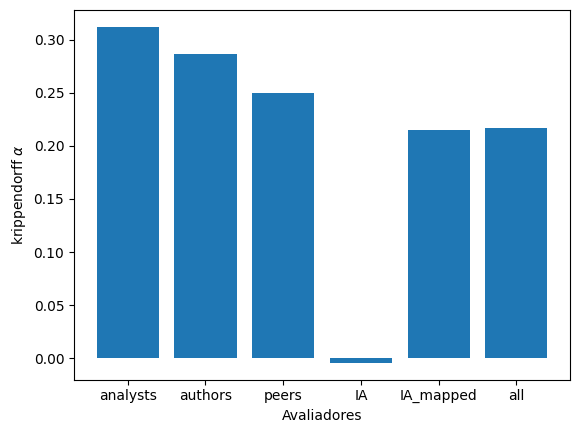

In [62]:
plt.bar(krippendorff_alpha.keys(), krippendorff_alpha.values())
plt.xlabel('Avaliadores')
plt.ylabel(r'krippendorff $\alpha$')

In [63]:
#TODO: Ponderação por peso de tema

In [64]:
#TODO: 